In [1]:
import sys 
sys.path.append("../")

import importlib
from functools import partial

import matplotlib.pyplot as plt
import numpy as np  
from IPython.display import display
import pandas as pd 

import torch
import torch.nn.functional as F
from torch_geometric.loader import DataLoader
from torch_geometric.utils import from_networkx

In [2]:
# Reproducibility
SEED = 123123
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = True 
np.random.seed(SEED)

In [3]:
DATASET_NAME = "PROTEINS"

In [4]:
config = {
    "DATASET_NAME": DATASET_NAME, 
    "device": "cpu",
    "explainee": {
        "epochs": 200, 
        "batch_size": 32, 
        "lr": 1e-3
    }, 
    "ged_model": {
        "n_perds": 1, 
        "epochs": 100, 
        "batch_size": 32, 
    }, 
    "tune": {
        "n_trials": 8, 
        "max_nodes": 24, 
        "iters_per_sample": 16, 
        "samples_per_trial": 8, # Note: per class. 
    },
    "train": {
        "iters_per_sample": 200, 
        "samples_per_trial": 50, # Note: per class. 
    }
}

# Data

In [5]:
import new_src.dataAdapter
from new_src.dataAdapter import load_dataset
importlib.reload(new_src.dataAdapter)

data = load_dataset(config.get("DATASET_NAME"))
cls_split = data.split_by_class()

# Explainee

In [6]:
import new_src.explainee
from new_src.explainee import fit_explainee
importlib.reload(new_src.explainee)

explainee, _ = fit_explainee(
    dataset_name = config.get("DATASET_NAME"),
    root="data",
    hidden=64,
    layers=3,
    dropout=0.2,
    epochs=config["explainee"]["epochs"],
    batch_size=config["explainee"]["batch_size"],
    lr=config["explainee"]["lr"],
    device=config.get("device")
)


# Extract embeddings. 
mean_embeds = [
    torch.cat([explainee(batch.to(config.get("device")))["embeds"]
               for batch in DataLoader(subset, batch_size=64)])
         .mean(dim=0)
    for subset in cls_split
]
mean_embeds = [m.detach() for m in mean_embeds]

[001/200] train_loss=0.6493  val_acc=0.784
[002/200] train_loss=0.5927  val_acc=0.811
[003/200] train_loss=0.5787  val_acc=0.775
[004/200] train_loss=0.5449  val_acc=0.802
[005/200] train_loss=0.5382  val_acc=0.775
[006/200] train_loss=0.5583  val_acc=0.793
[007/200] train_loss=0.5525  val_acc=0.793
[008/200] train_loss=0.5451  val_acc=0.757
[009/200] train_loss=0.5365  val_acc=0.820
[010/200] train_loss=0.5392  val_acc=0.811
[011/200] train_loss=0.5388  val_acc=0.784
[012/200] train_loss=0.5363  val_acc=0.811
[013/200] train_loss=0.5316  val_acc=0.802
[014/200] train_loss=0.5258  val_acc=0.802
[015/200] train_loss=0.5384  val_acc=0.802
[016/200] train_loss=0.5197  val_acc=0.802
[017/200] train_loss=0.5265  val_acc=0.811
[018/200] train_loss=0.5339  val_acc=0.766
[019/200] train_loss=0.5235  val_acc=0.811
[020/200] train_loss=0.5233  val_acc=0.811
[021/200] train_loss=0.5158  val_acc=0.811
[022/200] train_loss=0.5334  val_acc=0.802
[023/200] train_loss=0.5223  val_acc=0.811
[024/200] t

# GED Approximator

Generating synthetic GED dataset with 1 perturbations per graph...
Created GED dataset with 1113 pairs.


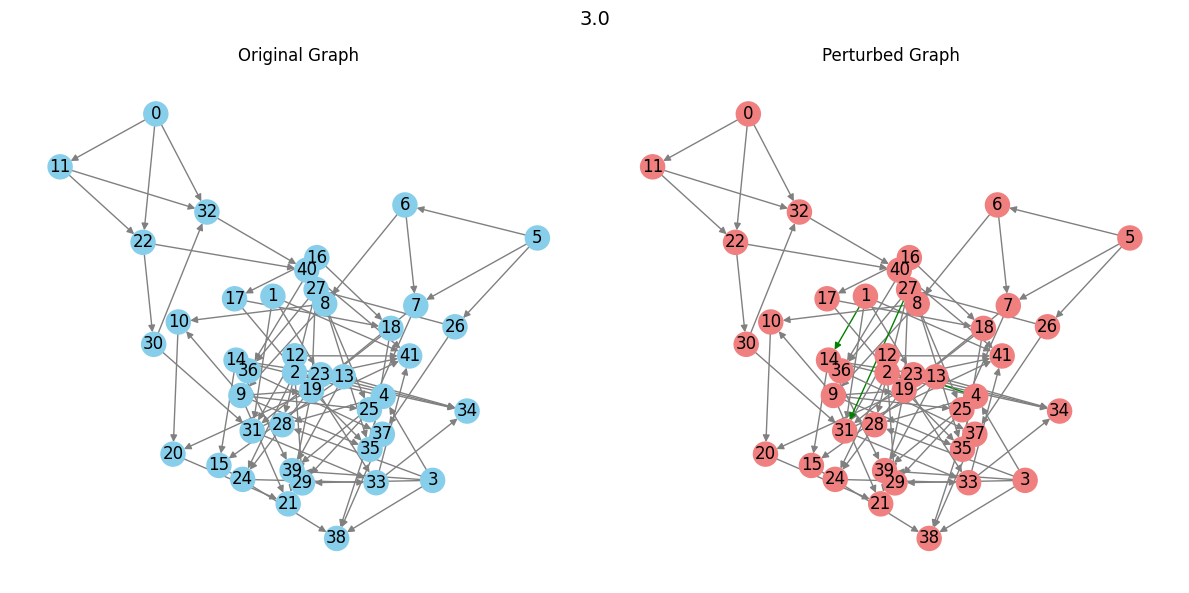

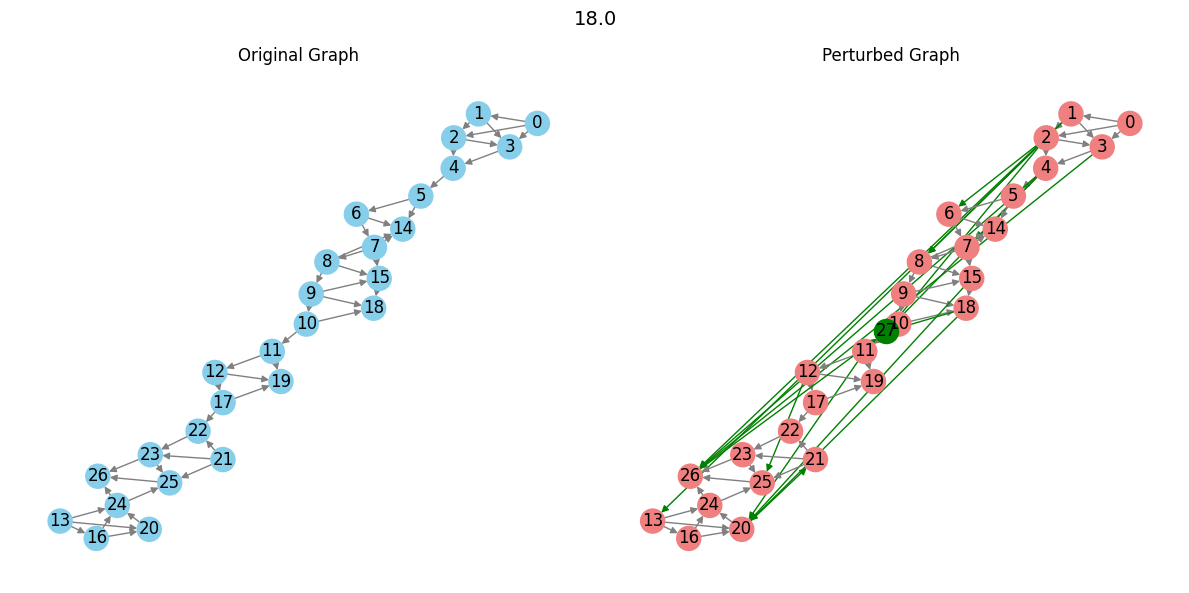

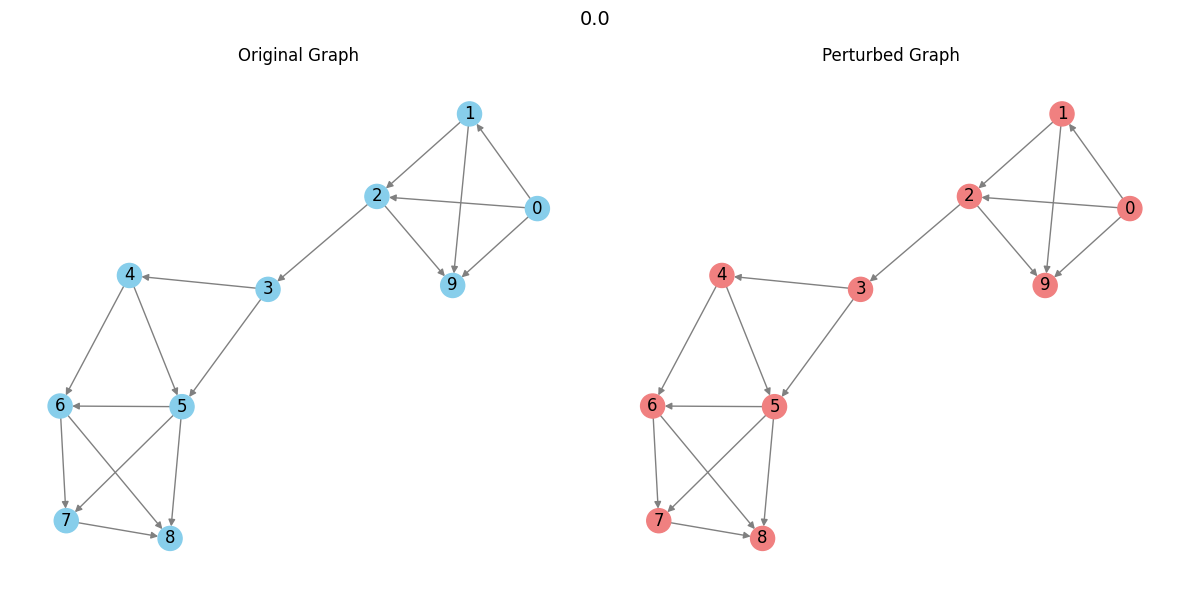

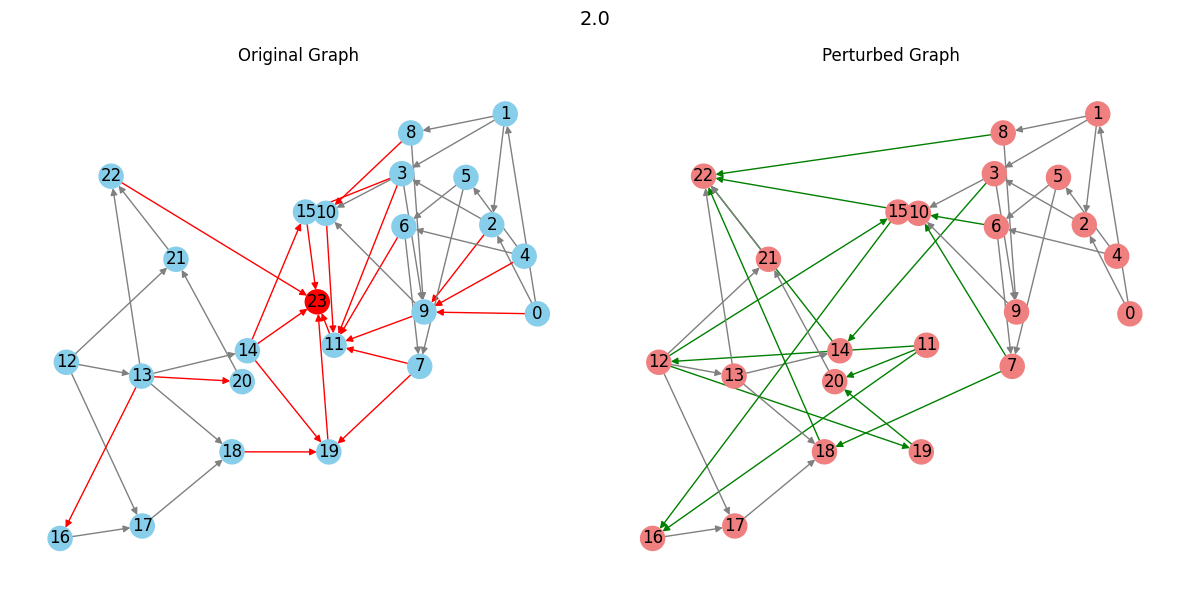

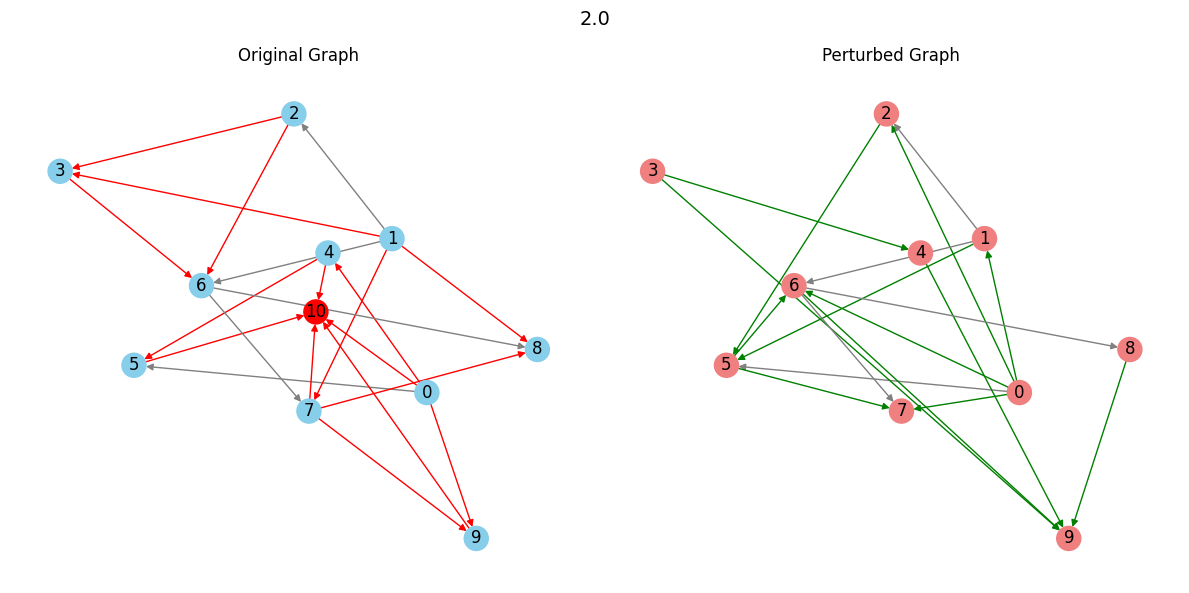

In [7]:
import new_src.ged_dataset
importlib.reload(new_src.ged_dataset)

from new_src.ged_dataset import create_and_save_ged_dataset, plot_graph_pair

ged_dataset = create_and_save_ged_dataset(
    data, 
    out_path=None, 
    n_perturbations=config["ged_model"]["n_perds"],
    node_add_prob=0.5,
    node_remove_prob=0.5,
    edge_add_prob=0.1, 
    edge_remove_prob=0.1
)

print(f"Created GED dataset with {len(ged_dataset)} pairs.")

for i in range(5):
    g1, g2, ged_norm, _, _ = ged_dataset[i]
    raw_ged = getattr(g1, "raw_ged", ged_norm)
    plot_graph_pair(g1, g2, label=raw_ged)

In [8]:
import new_src.simgnn
importlib.reload(new_src.simgnn)

from new_src.simgnn import SimGNN, train_simgnn

model = SimGNN(in_dim=len(data.NODE_CLS))

train_simgnn(
    model=(m := model), 
    data=ged_dataset, 
    batch_size=config["ged_model"]["batch_size"], 
    optimizer=(o := torch.optim.Adam(m.parameters(), lr=1e-3)),
    scheduler=torch.optim.lr_scheduler.ExponentialLR(o, gamma=1),
    epochs=config["ged_model"]["epochs"], 
    device=config.get("device")
)

Training SimGNN:   0%|          | 0/100 [00:00<?, ?it/s]

Epoch 001 | Loss: 38.5042 | MSE(norm): 38.5042 | MSE(raw): 148671872.0000 | Corr(norm): 0.1309 | Corr(raw): 0.5195
Epoch 002 | Loss: 28.1066 | MSE(norm): 28.1066 | MSE(raw): 79781368.0000 | Corr(norm): 0.0539 | Corr(raw): -0.2723
Epoch 003 | Loss: 35.9746 | MSE(norm): 35.9746 | MSE(raw): 236667248.0000 | Corr(norm): -0.1953 | Corr(raw): -0.8039
Epoch 004 | Loss: 4.3318 | MSE(norm): 4.3318 | MSE(raw): 9436313.0000 | Corr(norm): 0.2362 | Corr(raw): 0.7700
Epoch 005 | Loss: 6.4416 | MSE(norm): 6.4416 | MSE(raw): 5840572.0000 | Corr(norm): 0.0761 | Corr(raw): 0.1985
Epoch 006 | Loss: 7.4604 | MSE(norm): 7.4604 | MSE(raw): 24341972.0000 | Corr(norm): 0.1304 | Corr(raw): 0.4106
Epoch 007 | Loss: 3.1534 | MSE(norm): 3.1534 | MSE(raw): 10264223.0000 | Corr(norm): 0.1314 | Corr(raw): 0.1414
Epoch 008 | Loss: 1.4779 | MSE(norm): 1.4779 | MSE(raw): 7223655.0000 | Corr(norm): 0.2634 | Corr(raw): 0.9145
Epoch 009 | Loss: 10.6566 | MSE(norm): 10.6566 | MSE(raw): 73782864.0000 | Corr(norm): -0.1848 |

# Generator

In [9]:
# All passes should be explicit. 
def train_generator(
    cls_idx, 
    max_nodes, 
    iters_per_sample, 
    data, 
    mean_embeds, 
    explainee, 
    ged_model, 
    w_pred=1,
    w_embed=1,
    w_ged=1,
    w_mcs=1,
    w_spec=1,
    w_wl=1,
    use_omega=False,  
):

    from new_src.graph_sampler import GraphSampler
    from new_src.trainer import Trainer
    from new_src.criteria import (
        WeightedCriterion, 
        ClassScoreCriterion, 
        EmbeddingCriterion, 
        BudgetPenalty
    )
    
    from new_src.graph_level_dist import (
        neural_approx_ged_dist, 
        mcs_soft_graph_dist, 
        spectral_dist, 
        wl_graph_kernel_dist
    )
    
    trainer = Trainer(
        sampler=(
            s := GraphSampler(
                    max_nodes=max_nodes,
                    num_node_cls=len(data.NODE_CLS),
                    num_edge_cls=len(data.EDGE_CLS), 
                    temperature=0.15,
                    learn_node_feat=len(data.NODE_CLS) > 0, 
                    learn_edge_feat=len(data.EDGE_CLS) > 0, 
            )
        ),
        discriminator=explainee,
        criterion=WeightedCriterion([
            dict(key="logits", 
                criterion=ClassScoreCriterion(
                    class_idx=cls_idx, mode='maximize'
                ), 
                weight=w_pred
            ),
            dict(key="embeds", 
                criterion=EmbeddingCriterion(
                    target_embedding=mean_embeds[cls_idx]
                ), 
                weight=w_embed
            ),
            dict(key="cont_data", 
                criterion=neural_approx_ged_dist(
                    data = data, model = ged_model, explainee=explainee, 
                    cls_idx=cls_idx, 
                    use_omega=use_omega
                ), 
                weight=w_ged
            ), 
            dict(key="cont_data", 
                criterion=mcs_soft_graph_dist(
                    data = data, explainee=explainee, 
                    cls_idx=cls_idx, 
                    use_omega=use_omega
                ), 
                weight=w_mcs
            ), 
            dict(key="cont_data", 
                criterion=spectral_dist(
                    data = data, explainee=explainee, 
                    cls_idx=cls_idx, 
                    use_omega=use_omega
                ), 
                weight=w_spec
            ), 
            dict(key="cont_data", 
                criterion=wl_graph_kernel_dist(
                    data = data, explainee=explainee, 
                    cls_idx=cls_idx, 
                    use_omega=use_omega
                ), 
                weight=w_wl
            ), 
        ]),
        optimizer=(o := torch.optim.SGD(s.parameters(), lr=1)),
        scheduler=torch.optim.lr_scheduler.ExponentialLR(o, gamma=1),
        dataset=data,
        budget_penalty=BudgetPenalty(budget=20, order=2, beta=1),
        device=config.get("device")
    )

    trainer.train(
        iterations=iters_per_sample,
        target_probs={cls_idx: (0.9, 1.0)},
        target_size=30,
        w_budget_init=0.5,
        w_budget_inc=1.1,
        w_budget_dec=0.95,
        k_samples=32
    )

    example = trainer.evaluate(threshold=0.5)

    example = from_networkx(example)

    if "label" in example: 
        example.x = F.one_hot(
            example.label, num_classes=len(data.NODE_CLS)
        ).float()

    if "edge_label" in example: 
        example.edge_attr = F.one_hot(
            example.edge_label, num_classes=len(data.EDGE_CLS)
        ).float()

    example.y = torch.tensor(cls_idx).float()
    
    return example

## Tuning

In [10]:
import ray
from ray import tune
from ray import air
from ray.tune import ExperimentAnalysis
ray.shutdown()
ray.init(
    runtime_env={
        "py_modules": ["/repo/revisions/new_src"]
    },
    num_gpus=1
)

data_ref = ray.put(data)
mean_embeds_ref = ray.put(mean_embeds)
cls_split_ref = ray.put(data.split_by_class())

2025-11-12 19:46:24,071	WARNING services.py:2155 -- WARNING: The object store is using /tmp instead of /dev/shm because /dev/shm has only 67104768 bytes available. This will harm performance! You may be able to free up space by deleting files in /dev/shm. If you are inside a Docker container, you can increase /dev/shm size by passing '--shm-size=10.24gb' to 'docker run' (or add it to the run_options list in a Ray cluster config). Make sure to set this to more than 30% of available RAM.
2025-11-12 19:46:24,284	INFO worker.py:2012 -- Started a local Ray instance.
2025-11-12 19:46:24,779	INFO packaging.py:588 -- Creating a file package for local module '/repo/revisions/new_src'.
2025-11-12 19:46:25,337	INFO packaging.py:380 -- Pushing file package 'gcs://_ray_pkg_0763045b3f3ad372.zip' (0.39MiB) to Ray cluster...
2025-11-12 19:46:25,341	INFO packaging.py:393 -- Successfully pushed file package 'gcs://_ray_pkg_0763045b3f3ad372.zip'.
/opt/venv/lib/python3.12/site-packages/ray/_private/worker

In [11]:
def tune_generator(
    config, *,
    explainee, 
    model, 
    max_nodes, 
    gen_samples, 
    iters_per_sample, 
):
    from new_src.eval import eval_summary
    from new_src.graph_level_dist import neural_approx_ged_dist

    data = ray.get(data_ref) 
    mean_embeds = ray.get(mean_embeds_ref)
    cls_split = ray.get(cls_split_ref)
   
    w_pred  = float(config["pred_weight"])
    w_embed = float(config["embed_weight"])
    w_ged   = float(config["ged_weight"])
    w_mcs   = float(config["mcs_weight"])
    w_spec  = float(config["spectral_weight"])
    w_wl    = float(config["wl_weight"])
    use_omega = bool(config["use_omega"])
    
    graphs_0 = [
        train_generator(
            cls_idx=0, 
            max_nodes=max_nodes, 
            iters_per_sample=iters_per_sample, 
            data=data, 
            explainee=explainee, 
            mean_embeds=mean_embeds, 
            ged_model=model, 
            w_pred=w_pred, 
            w_embed=w_embed, 
            w_ged=w_ged, 
            w_mcs=w_mcs, 
            w_spec=w_spec, 
            w_wl=w_wl, 
            use_omega = use_omega
        ) 
        for _ in range(gen_samples)
    ] 

    graphs_1 = [
        train_generator(
            cls_idx=1, 
            max_nodes=max_nodes, 
            iters_per_sample=iters_per_sample, 
            data=data, 
            explainee=explainee, 
            mean_embeds=mean_embeds, 
            ged_model=model, 
            w_pred=w_pred, 
            w_embed=w_embed, 
            w_ged=w_ged, 
            w_mcs=w_mcs, 
            w_spec=w_spec, 
            w_wl=w_wl, 
            use_omega = use_omega
        ) 
        for _ in range(gen_samples)
    ] 
    
    dist_to_0 = neural_approx_ged_dist(cls_split[0], model)
    dist_to_1 = neural_approx_ged_dist(cls_split[1], model)
     
    score = eval_summary(
        explainee, graphs_0, graphs_1,
        cls_split[0], cls_split[1], 
        dist_to_0, dist_to_1
    ) 
    
    results = {
        "score": float(score)
    }

    tune.report(results)

    return results

In [12]:
possible_weight = [0.0, 1e-2, 1e-1, 1.0, 1e+1, 1e+2]
search_space = {
    "pred_weight": tune.choice(possible_weight),
    "embed_weight": tune.choice(possible_weight),
    "ged_weight": tune.choice(possible_weight),
    "mcs_weight": tune.choice(possible_weight),
    "spectral_weight": tune.choice(possible_weight),
    "wl_weight": tune.choice(possible_weight),
    "use_omega": tune.choice([True, False])
}

trainable = tune.with_parameters(
    tune_generator, 
    explainee=explainee,
    model=model, 
    max_nodes=config["tune"]["max_nodes"],
    gen_samples=config["tune"]["samples_per_trial"], 
    iters_per_sample=config["tune"]["iters_per_sample"]
)

gen_tuner = tune.Tuner(
    trainable=tune.with_resources(
        trainable, 
        resources={"gpu": 1}
    ), 
    param_space=search_space,
    tune_config=tune.TuneConfig(
        num_samples=config["tune"]["n_trials"],  
        metric="score",
        mode="max"
    ), 
)

In [13]:
tune_results = gen_tuner.fit()

 81%|████████▏ | 13/16 [00:06<00:01,  2.70it/s, size=7.73, bpw=0.5, non-enzyme=-0.474, enzyme=0.64] 
(bundle_reservation_check_func pid=10222) [2025-11-12 19:47:36,083 E 10222 10275] core_worker_process.cc:825: Failed to establish connection to the metrics exporter agent. Metrics will not be exported. Exporter agent status: RpcError: Running out of retries to initialize the metrics agent. rpc_code: 14
 50%|█████     | 8/16 [00:03<00:03,  2.03it/s, size=6.42, bpw=0.5, non-enzyme=-1.12, enzyme=1.2]
(tune_generator pid=10315) [2025-11-12 19:47:38,654 E 10315 10359] core_worker_process.cc:825: Failed to establish connection to the metrics exporter agent. Metrics will not be exported. Exporter agent status: RpcError: Running out of retries to initialize the metrics agent. rpc_code: 14
100%|██████████| 16/16 [00:07<00:00,  2.19it/s, size=12.5, bpw=0.5, non-enzyme=0.45, enzyme=-0.391]


(tune_generator pid=10315) Prediction Interval Class 0 0.5492803454399109 +/- 0.18822601437568665
(tune_generator pid=10315) 
(tune_generator pid=10315) Prediction Interval Class 1 0.6397014856338501 +/- 0.23459555208683014
(tune_generator pid=10315) 
(tune_generator pid=10315) Counterfactual Shift to Class 0 0.32673171162605286 +/- 0.2203296720981598
(tune_generator pid=10315) 
(tune_generator pid=10315) Counterfactual Shift to Class 1 -0.11355102807283401 +/- 0.12213512510061264
(tune_generator pid=10315) 
(tune_generator pid=10315) Class 0 Perturbation Sensitivity 0.03280314430594444 +/- 0.03529895097017288
(tune_generator pid=10315) 
(tune_generator pid=10315) Class 1 Perturbation Sensitivity 0.027076328173279762 +/- 0.032418884336948395
(tune_generator pid=10315) 
(tune_generator pid=10315) Relative Distance to Class 0 0.7260042428970337 +/- 0.7419517636299133 
(tune_generator pid=10315) 
(tune_generator pid=10315) Relative Distance to Class 1 0.0705617368221283 +/- 0.979956448078

  0%|          | 0/16 [00:00<?, ?it/s]
(tune_generator pid=10785) [2025-11-12 19:49:53,872 E 10785 10829] core_worker_process.cc:825: Failed to establish connection to the metrics exporter agent. Metrics will not be exported. Exporter agent status: RpcError: Running out of retries to initialize the metrics agent. rpc_code: 14
100%|██████████| 16/16 [00:07<00:00,  2.09it/s, size=9.92, bpw=0.5, non-enzyme=-0.654, enzyme=0.732]


(tune_generator pid=10785) 
(tune_generator pid=10785) 
(tune_generator pid=10785) 
(tune_generator pid=10785) 
(tune_generator pid=10785) 
(tune_generator pid=10785) 
(tune_generator pid=10785) 
(tune_generator pid=10785) 
(tune_generator pid=10785) Prediction Interval Class 1 0.7679152488708496 +/- 0.19314174354076385 [repeated 2x across cluster]
(tune_generator pid=10785) Counterfactual Shift to Class 1 -0.11936020106077194 +/- 0.13082104921340942 [repeated 2x across cluster]
(tune_generator pid=10785) Class 1 Perturbation Sensitivity 0.03378627821803093 +/- 0.046913813799619675 [repeated 2x across cluster]
(tune_generator pid=10785) Relative Distance to Class 1 -0.03216949850320816 +/- 0.40652430057525635  [repeated 2x across cluster]


100%|██████████| 16/16 [00:09<00:00,  1.66it/s, size=11, bpw=0.5, non-enzyme=0.449, enzyme=-0.401]


...

 94%|█████████▍| 15/16 [00:07<00:00,  2.32it/s, size=10.5, bpw=0.5, non-enzyme=0.511, enzyme=-0.465]
(tune_generator pid=13002) [2025-11-12 20:01:49,744 E 13002 13046] core_worker_process.cc:825: Failed to establish connection to the metrics exporter agent. Metrics will not be exported. Exporter agent status: RpcError: Running out of retries to initialize the metrics agent. rpc_code: 14
100%|██████████| 16/16 [00:09<00:00,  1.69it/s, size=8.35, bpw=0.5, non-enzyme=-0.0497, enzyme=0.122]


(tune_generator pid=13002) 
(tune_generator pid=13002) 
(tune_generator pid=13002) 
(tune_generator pid=13002) 
(tune_generator pid=13002) 
(tune_generator pid=13002) 
(tune_generator pid=13002) 
(tune_generator pid=13002) 
(tune_generator pid=13002) Prediction Interval Class 1 0.637950599193573 +/- 0.29742521047592163 [repeated 2x across cluster]
(tune_generator pid=13002) Counterfactual Shift to Class 1 -0.12820594012737274 +/- 0.12524907290935516 [repeated 2x across cluster]
(tune_generator pid=13002) Class 1 Perturbation Sensitivity 0.017427915707230568 +/- 0.02495344914495945 [repeated 2x across cluster]
(tune_generator pid=13002) Relative Distance to Class 1 -0.5086984634399414 +/- 0.6540504097938538  [repeated 2x across cluster]


100%|██████████| 16/16 [00:07<00:00,  2.08it/s, size=15.4, bpw=0.5, non-enzyme=0.343, enzyme=-0.293]
(tune_generator pid=13387) [2025-11-12 20:04:04,624 E 13387 13432] core_worker_process.cc:825: Failed to establish connection to the metrics exporter agent. Metrics will not be exported. Exporter agent status: RpcError: Running out of retries to initialize the metrics agent. rpc_code: 14
 19%|█▉        | 3/16 [00:01<00:08,  1.62it/s, size=6.41, bpw=0.5, non-enzyme=-0.826, enzyme=0.692]
2025-11-12 20:05:37,958	INFO tune.py:1009 -- Wrote the latest version of all result files and experiment state to '/root/ray_results/tune_generator_2025-11-12_19-47-03' in 0.0056s.


(tune_generator pid=13387) 
(tune_generator pid=13387) 
(tune_generator pid=13387) 
(tune_generator pid=13387) 
(tune_generator pid=13387) 
(tune_generator pid=13387) 
(tune_generator pid=13387) 
(tune_generator pid=13387) 
(tune_generator pid=13387) Prediction Interval Class 1 0.8589704036712646 +/- 0.04862024635076523 [repeated 2x across cluster]
(tune_generator pid=13387) Counterfactual Shift to Class 1 -0.0981978103518486 +/- 0.10749321430921555 [repeated 2x across cluster]
(tune_generator pid=13387) Class 1 Perturbation Sensitivity 0.022443870082497597 +/- 0.02835100330412388 [repeated 2x across cluster]
(tune_generator pid=13387) Relative Distance to Class 1 -0.07284664362668991 +/- 0.5164023637771606  [repeated 2x across cluster]


2025-11-12 20:05:37,966	INFO tune.py:1041 -- Total run time: 1114.54 seconds (1114.40 seconds for the tuning loop).


Best configuration: {'pred_weight': 0.1, 'embed_weight': 0.1, 'ged_weight': 100.0, 'mcs_weight': 0.01, 'spectral_weight': 0.1, 'wl_weight': 10.0, 'use_omega': True}


,score,timestamp,checkpoint_dir_name,done,training_iteration,trial_id,date,time_this_iter_s,time_total_s,pid,...,time_since_restore,iterations_since_restore,config/pred_weight,config/embed_weight,config/ged_weight,config/mcs_weight,config/spectral_weight,config/wl_weight,config/use_omega,logdir
0,0.545717,1762976960,None,False,2,5c987_00000,2025-11-12_19-49-20,0.000838,128.034159,10315,...,128.034159,2,0.0,100.00,100.0,1.00,0.10,100.00,False,5c987_00000
1,1.087713,1762977099,None,False,2,5c987_00001,2025-11-12_19-51-39,0.022990,131.467253,10785,...,131.467253,2,0.1,0.01,10.0,100.00,0.01,0.10,True,5c987_00001
2,1.467086,1762977255,None,False,2,5c987_00002,2025-11-12_19-54-15,0.000909,148.859705,11260,...,148.859705,2,1.0,100.00,0.1,10.00,0.00,0.00,True,5c987_00002
3,2.248600,1762977402,None,False,2,5c987_00003,2025-11-12_19-56-42,0.012218,141.059143,11752,...,141.059143,2,0.1,0.10,100.0,0.01,0.10,10.00,True,5c987_00003
4,0.955003,1762977550,None,False,2,5c987_00004,2025-11-12_19-59-10,0.023268,141.184875,12201,...,141.184875,2,0.0,10.00,0.1,100.00,100.00,0.01,True,5c987_00004
5,2.108914,1762977676,None,False,2,5c987_00005,2025-11-12_20-01-16,0.000923,117.558056,12630,...,117.558056,2,10.0,10.00,0.0,10.00,100.00,10.00,False,5c987_00005
6,1.607208,1762977811,None,False,2,5c987_00006,2025-11-12_20-03-31,0.000718,126.212961,13002,...,126.212961,2,0.0,0.10,100.0,0.10,10.00,0.10,True,5c987_00006
7,1.519174,1762977937,None,False,2,5c987_00007,2025-11-12_20-05-37,0.014584,118.009642,13387,...,118.009642,2,100.0,0.10,0.0,0.00,0.00,1.00,False,5c987_00007


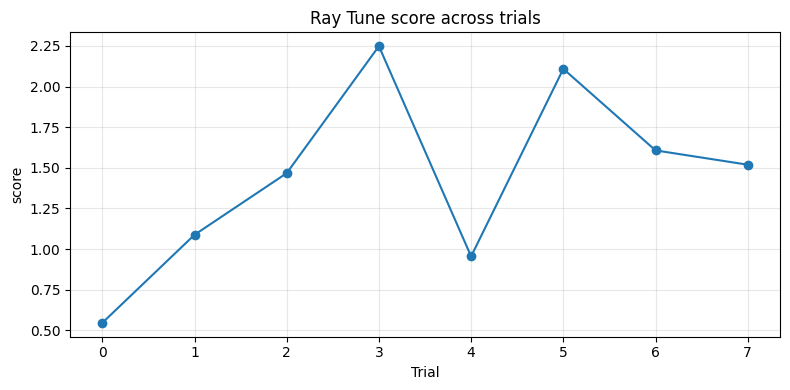

In [14]:
best_config = tune_results.get_best_result().config
print("Best configuration:", best_config)

df = tune_results.get_dataframe()
display(df)

df_sorted = df.reset_index(drop=True)

plt.figure(figsize=(8, 4))
plt.plot(df_sorted.index.to_numpy(), df_sorted["score"].to_numpy(), marker="o")
plt.xlabel("Trial")
plt.ylabel("score")
plt.title("Ray Tune score across trials")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Evaluation

In [15]:

graphs_0 = [
    train_generator(
        cls_idx=0, 
        max_nodes=config['tune']['max_nodes'], 
        iters_per_sample=config['train']['iters_per_sample'], 
        data=data, 
        mean_embeds=mean_embeds, 
        explainee=explainee, 
        ged_model=model, 
        w_pred  = float(best_config["pred_weight"]), 
        w_embed = float(best_config["embed_weight"]),
        w_ged   = float(best_config["ged_weight"]), 
        w_mcs   = float(best_config["mcs_weight"]),
        w_spec  = float(best_config["spectral_weight"]),
        w_wl    = float(best_config["wl_weight"]),
        use_omega = bool(best_config["use_omega"])
    ) for _ in range(config['train']['samples_per_trial'])
]

graphs_1 = [
    train_generator(
        cls_idx=1, 
        max_nodes=config['tune']['max_nodes'], 
        iters_per_sample=config['train']['iters_per_sample'], 
        data=data, 
        mean_embeds=mean_embeds, 
        explainee=explainee, 
        ged_model=model, 
        w_pred  = float(best_config["pred_weight"]), 
        w_embed = float(best_config["embed_weight"]),
        w_ged   = float(best_config["ged_weight"]), 
        w_mcs   = float(best_config["mcs_weight"]),
        w_spec  = float(best_config["spectral_weight"]),
        w_wl    = float(best_config["wl_weight"]),
        use_omega = bool(best_config["use_omega"])
    ) for _ in range(config['train']['samples_per_trial'])
]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

...

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

In [17]:
import new_src.graph_level_dist
importlib.reload(new_src.graph_level_dist)

from new_src.graph_level_dist import neural_approx_ged_dist
dist_to_0 = neural_approx_ged_dist(cls_split[0], model)
dist_to_1 = neural_approx_ged_dist(cls_split[1], model)

import new_src.eval
importlib.reload(new_src.eval)

from new_src.eval import eval_summary


eval_summary(
    explainee=explainee, 
    gen_graphs_0=graphs_0,
    gen_graphs_1=graphs_1, 
    obs_graphs_0=cls_split[0], 
    obs_graphs_1=cls_split[1], 
    dist_to_0=dist_to_0, 
    dist_to_1=dist_to_1
)

Prediction Interval Class 0 0.48999157547950745 +/- 0.16306772828102112

Prediction Interval Class 1 0.822902500629425 +/- 0.16723254323005676

Counterfactual Shift to Class 0 0.3191716969013214 +/- 0.2408013492822647

Counterfactual Shift to Class 1 -0.11744421720504761 +/- 0.1291453242301941

Class 0 Perturbation Sensitivity 0.031278904527425766 +/- 0.04024839028716087

Class 1 Perturbation Sensitivity 0.023882737383246422 +/- 0.03340868651866913

Relative Distance to Class 0 0.43741172552108765 +/- 0.5570376515388489 

Relative Distance to Class 1 -0.3010788559913635 +/- 0.7007185220718384 



1.32312704436481

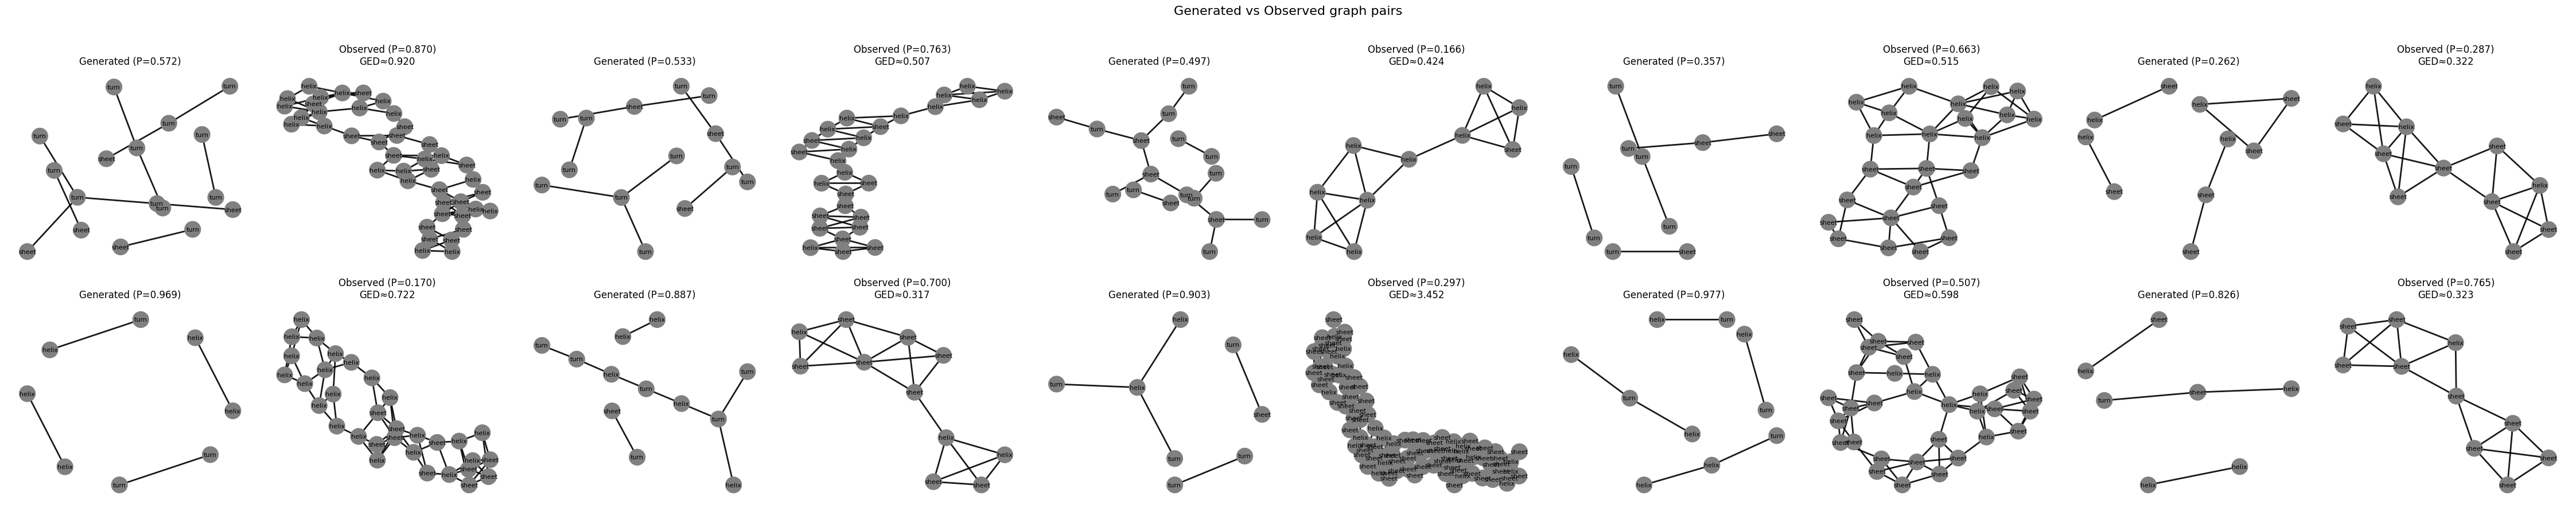

In [18]:
import new_src.utils
importlib.reload(new_src.utils)

from new_src.utils import eval_plot 

eval_plot(
    explainee, 
    graphs_0, 
    graphs_1, 
    obs_graphs_0=cls_split[0], 
    obs_graphs_1=cls_split[1],
    ged_model=model, 
    dataset=data,
    layout="kamada"
)